In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from datetime import datetime, timedelta

In [8]:
path_data = os.getcwd() + '/data/'
path_demand = path_data + 'output/csv/demand/'
path_loads =path_data + 'loads/'
path_generation = path_data + 'generators_profiles/'
path_losses = path_data + 'output/csv/losses/'
path_bess = path_data + 'output/csv/bess/'

In [9]:
demand_NoOperation = path_demand + 'Demand_NoOperation_year_CondominioDosIpes.csv'
demand_RL = path_demand + 'rl_forecasting_results_test.csv'
bess_RL = path_bess + 'rl_forecasting_bess_power_test.csv'

In [10]:
demand_values = pd.read_csv(demand_NoOperation)
demand_rl_values = pd.read_csv(demand_RL)
bess_rl_values = pd.read_csv(bess_RL)
bess_rl_values['Timestep'] = pd.to_datetime(bess_rl_values['Timestep'])
demand_values['Timestep'] = pd.to_datetime(demand_values['Timestep'])
demand_rl_values['Timestep'] = pd.to_datetime(demand_rl_values['Timestep'])
date_ini = '2012-07-08 06:05'
date_end = '2012-07-09 06:00'
time = pd.date_range(start=date_ini, end=date_end, freq='5T')
demand_values = demand_values[(demand_values['Timestep'] >= date_ini) & (demand_values['Timestep'] <= date_end)]
demand_rl_values = demand_rl_values[(demand_rl_values['Timestep'] >= date_ini) & (demand_rl_values['Timestep'] <= date_end)]
bess_rl_values = bess_rl_values[(bess_rl_values['Timestep'] >= date_ini) & (bess_rl_values['Timestep'] <= date_end)]



C:\Users\joao9\AppData\Local\Temp\ipykernel_13868\4040933227.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time = pd.date_range(start=date_ini, end=date_end, freq='5T')


In [11]:

def calcular_data_final(data_inicial_str: str, num_timesteps: int, intervalo_min: int) -> datetime:
    """
    Calcula a data final dado:
      - data_inicial_str: string no formato 'YYYY-MM-DD HH:MM'
      - num_timesteps: quantidade de passos de tempo (>= 1)
      - intervalo_min: intervalo entre passos em minutos

    Convenção:
      - num_timesteps = 1  -> data_final = data_inicial
      - num_timesteps = 2  -> data_final = data_inicial + 1 * intervalo
    """
    if num_timesteps < 1:
        raise ValueError("num_timesteps deve ser >= 1")

    # Converte string para datetime
    data_inicial = datetime.strptime(data_inicial_str, "%Y-%m-%d %H:%M")

    # (num_timesteps - 1) porque o primeiro passo é na própria data_inicial
    delta_total = timedelta(minutes=intervalo_min * (num_timesteps - 1))
    data_final = data_inicial + delta_total
    return data_final

num_timesteps = 288       # por exemplo
intervalo_min = 5         # 5 minutos entre cada timestep
data_final = calcular_data_final(date_ini, num_timesteps, intervalo_min)

print(f"Data inicial : {date_ini}")
print(f"Timesteps    : {num_timesteps}")
print(f"Intervalo    : {intervalo_min} min")
print(f"Data final   : {data_final.strftime('%Y-%m-%d %H:%M')}")


Data inicial : 2012-07-08 06:05
Timesteps    : 288
Intervalo    : 5 min
Data final   : 2012-07-09 06:00


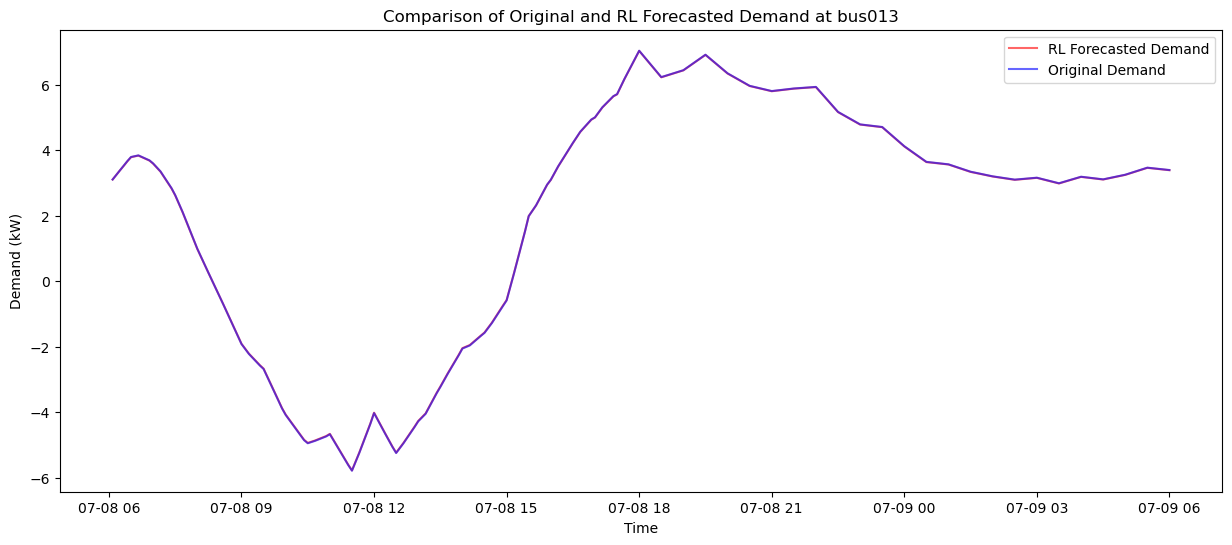

In [12]:
# plotting the demand values

plt.figure(figsize=(15, 6))
plt.plot(time, demand_rl_values['P(kW)'], label='RL Forecasted Demand', color='red', alpha=0.6)
plt.plot(time, demand_values['P(kW)'], label='Original Demand', color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Demand (kW)')
plt.title('Comparison of Original and RL Forecasted Demand at bus013')
plt.legend()